In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
import pandas as pd
import plotly.express as px

from sklearn.ensemble import IsolationForest

mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/nyc_taxi.csv')

In [3]:
df

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820
...,...,...
10315,2015-01-31 21:30:00,24670
10316,2015-01-31 22:00:00,25721
10317,2015-01-31 22:30:00,27309
10318,2015-01-31 23:00:00,26591


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  10320 non-null  object
 1   value      10320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 161.4+ KB


In [5]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  10320 non-null  datetime64[ns]
 1   value      10320 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 161.4 KB


In [7]:
df.head()

,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [8]:
df=df.set_index('timestamp').resample("H").mean().reset_index()

/tmp/ipykernel_1200289/1339179931.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df=df.set_index('timestamp').resample("H").mean().reset_index()


In [9]:
df

,timestamp,value
0,2014-07-01 00:00:00,9485.5
1,2014-07-01 01:00:00,5433.0
2,2014-07-01 02:00:00,3346.5
3,2014-07-01 03:00:00,2216.5
4,2014-07-01 04:00:00,2189.5
...,...,...
5155,2015-01-31 19:00:00,28288.5
5156,2015-01-31 20:00:00,24138.0
5157,2015-01-31 21:00:00,24194.5
5158,2015-01-31 22:00:00,26515.0


In [10]:
df['hour']=df.timestamp.dt.hour

In [11]:
df['weekday']=pd.Categorical(df.timestamp.dt.strftime('%A'), categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday', 'Sunday'], ordered=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5160 entries, 0 to 5159
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  5160 non-null   datetime64[ns]
 1   value      5160 non-null   float64       
 2   hour       5160 non-null   int32         
 3   weekday    5160 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), int32(1)
memory usage: 106.3 KB


In [13]:
df

,timestamp,value,hour,weekday
0,2014-07-01 00:00:00,9485.5,0,Tuesday
1,2014-07-01 01:00:00,5433.0,1,Tuesday
2,2014-07-01 02:00:00,3346.5,2,Tuesday
3,2014-07-01 03:00:00,2216.5,3,Tuesday
4,2014-07-01 04:00:00,2189.5,4,Tuesday
...,...,...,...,...
5155,2015-01-31 19:00:00,28288.5,19,Saturday
5156,2015-01-31 20:00:00,24138.0,20,Saturday
5157,2015-01-31 21:00:00,24194.5,21,Saturday
5158,2015-01-31 22:00:00,26515.0,22,Saturday


/tmp/ipykernel_1200289/1253795599.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[['value','weekday']].groupby('weekday').mean().plot()


<Axes: xlabel='weekday'>

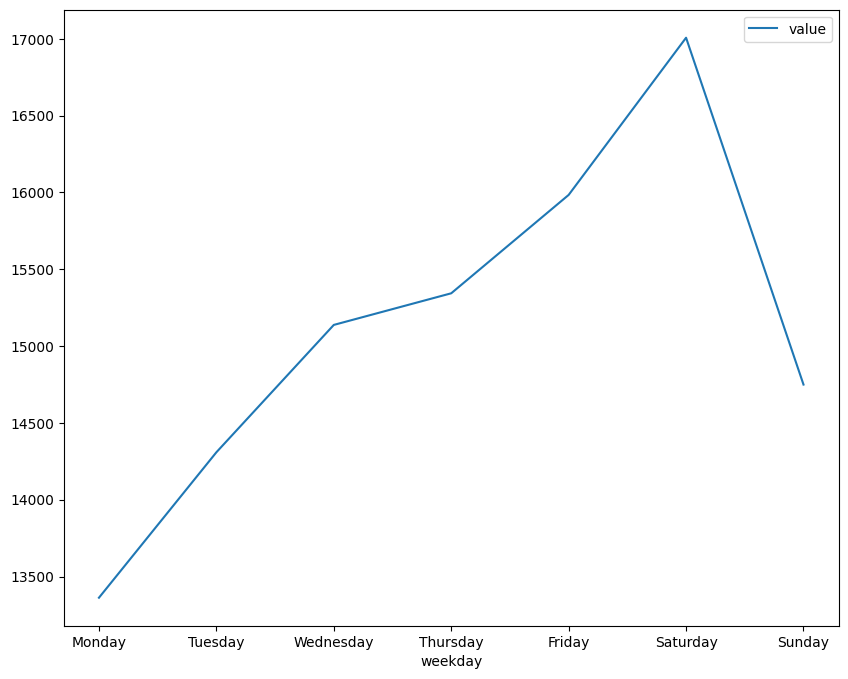

In [14]:
df[['value','weekday']].groupby('weekday').mean().plot()

<Axes: xlabel='hour'>

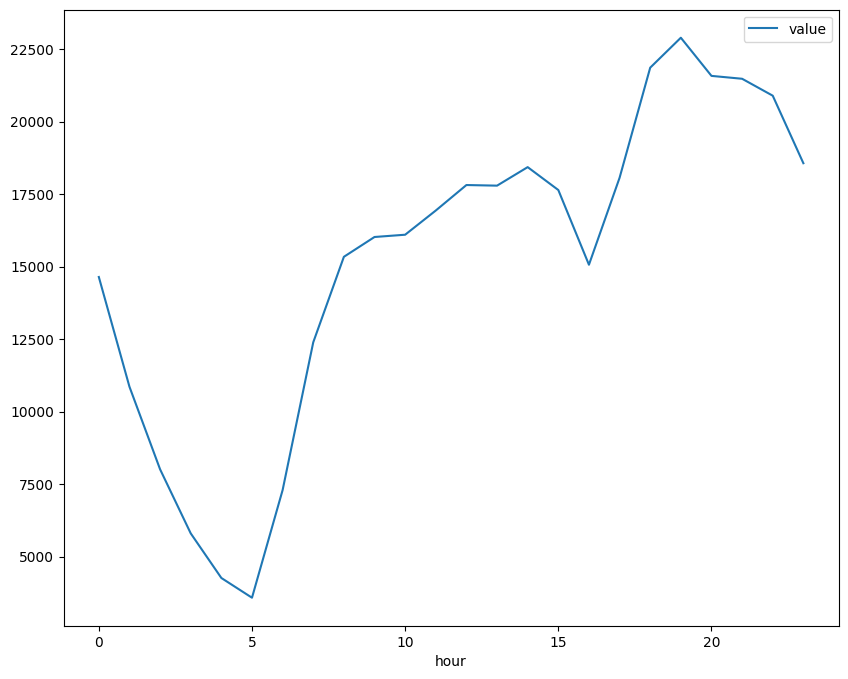

In [15]:
df[['value','hour']].groupby('hour').mean().plot()

In [16]:
fig = px.line(df.reset_index(), x='timestamp', y='value', title='NYC Taxi Demand')

fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

Anomalous Point

```
NYC Marathon - 2014-11-02
Thanksgiving - 2014-11-27
Christmas - 2014-12-25
New Years - 2015-01-01
Snow Blizzard - 2015-01-26 and 2015-01-27```



In [17]:
model =  IsolationForest(contamination=0.004)
model.fit(df[['value']])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.004
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [18]:
df['outliers']=pd.Series(model.predict(df[['value']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [19]:
df.query('outliers=="yes"')

,timestamp,value,hour,weekday,outliers
1631,2014-09-06 23:00:00,29418.5,23,Saturday,yes
2135,2014-09-27 23:00:00,28024.5,23,Saturday,yes
2639,2014-10-18 23:00:00,28253.5,23,Saturday,yes
2971,2014-11-01 19:00:00,27912.0,19,Saturday,yes
2977,2014-11-02 01:00:00,37204.5,1,Sunday,yes
3143,2014-11-08 23:00:00,27926.0,23,Saturday,yes
3311,2014-11-15 23:00:00,27713.0,23,Saturday,yes
3479,2014-11-22 23:00:00,28299.0,23,Saturday,yes
4417,2015-01-01 01:00:00,29292.0,1,Thursday,yes
4655,2015-01-10 23:00:00,28351.0,23,Saturday,yes


In [20]:
df

,timestamp,value,hour,weekday,outliers
0,2014-07-01 00:00:00,9485.5,0,Tuesday,no
1,2014-07-01 01:00:00,5433.0,1,Tuesday,no
2,2014-07-01 02:00:00,3346.5,2,Tuesday,no
3,2014-07-01 03:00:00,2216.5,3,Tuesday,no
4,2014-07-01 04:00:00,2189.5,4,Tuesday,no
...,...,...,...,...,...
5155,2015-01-31 19:00:00,28288.5,19,Saturday,yes
5156,2015-01-31 20:00:00,24138.0,20,Saturday,no
5157,2015-01-31 21:00:00,24194.5,21,Saturday,no
5158,2015-01-31 22:00:00,26515.0,22,Saturday,no


In [21]:
fig = px.scatter(df.reset_index(), x='timestamp', y='value', color='outliers', hover_data=['weekday'], title='NYC Taxi Demand')

fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

In [22]:
model =  IsolationForest()
model.fit(df[['value']])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [23]:
score=model.decision_function(df[['value']])

In [24]:
score

array([-0.02702284, -0.06974935, -0.00014936, ..., -0.01122759,
       -0.10270087, -0.10055782], shape=(5160,))

(array([  1.,   2.,   0.,   4.,   9.,   7.,   7.,   5.,   0.,   2.,   3.,
          6.,   3.,   7.,  10.,   9.,  10.,  16.,   7.,  13.,  28.,   9.,
         27.,  19.,  49., 121., 142., 174., 183., 183., 251., 102., 131.,
        282., 293., 356., 394., 296., 112.,  42.,  78., 254., 247., 147.,
        239., 170., 196.,  90., 217., 207.]),
 array([-0.22586317, -0.21969704, -0.21353091, -0.20736478, -0.20119865,
        -0.19503252, -0.18886639, -0.18270026, -0.17653413, -0.170368  ,
        -0.16420187, -0.15803574, -0.15186961, -0.14570348, -0.13953735,
        -0.13337122, -0.12720509, -0.12103896, -0.11487283, -0.1087067 ,
        -0.10254057, -0.09637444, -0.09020831, -0.08404218, -0.07787605,
        -0.07170992, -0.06554379, -0.05937766, -0.05321153, -0.0470454 ,
        -0.04087927, -0.03471314, -0.02854701, -0.02238088, -0.01621475,
        -0.01004862, -0.00388249,  0.00228364,  0.00844977,  0.0146159 ,
         0.02078203,  0.02694816,  0.03311429,  0.03928042,  0.04544655,
 

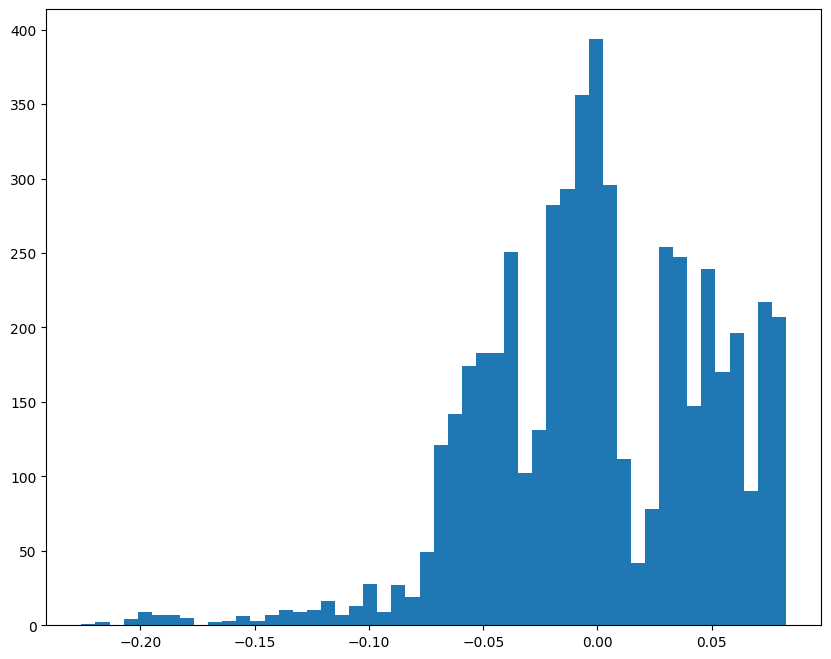

In [25]:
plt.hist(score, bins=50)

In [26]:
df['scores'] = score

In [27]:
df

,timestamp,value,hour,weekday,outliers,scores
0,2014-07-01 00:00:00,9485.5,0,Tuesday,no,-0.027023
1,2014-07-01 01:00:00,5433.0,1,Tuesday,no,-0.069749
2,2014-07-01 02:00:00,3346.5,2,Tuesday,no,-0.000149
3,2014-07-01 03:00:00,2216.5,3,Tuesday,no,-0.053810
4,2014-07-01 04:00:00,2189.5,4,Tuesday,no,-0.062582
...,...,...,...,...,...,...
5155,2015-01-31 19:00:00,28288.5,19,Saturday,yes,-0.203944
5156,2015-01-31 20:00:00,24138.0,20,Saturday,no,-0.008137
5157,2015-01-31 21:00:00,24194.5,21,Saturday,no,-0.011228
5158,2015-01-31 22:00:00,26515.0,22,Saturday,no,-0.102701


In [28]:
df.query('scores<-0.20')

,timestamp,value,hour,weekday,outliers,scores
1631,2014-09-06 23:00:00,29418.5,23,Saturday,yes,-0.217077
2639,2014-10-18 23:00:00,28253.5,23,Saturday,yes,-0.202517
2977,2014-11-02 01:00:00,37204.5,1,Sunday,yes,-0.225863
3479,2014-11-22 23:00:00,28299.0,23,Saturday,yes,-0.203944
4417,2015-01-01 01:00:00,29292.0,1,Thursday,yes,-0.214655
4655,2015-01-10 23:00:00,28351.0,23,Saturday,yes,-0.203944
5155,2015-01-31 19:00:00,28288.5,19,Saturday,yes,-0.203944
